# Garrido-Sanz & Keel (2025) — RhizCom Propagation Microbiome, Reproduced with Pyloseq

**Reference:** Garrido-Sanz, D., Keel, C. (2025). *RhizCom propagation: microbiome analyses.* Keel Lab, Department of Fundamental Microbiology, University of Lausanne.

The study follows **RhizCom** — a synthetic community assembled from wheat rhizosphere soil — through six serial propagation cycles. Starting from bulk soil (Soil), a washed rhizosphere inoculum (SoilWash) seeds six successive plant-associated growth cycles (Cycle1–Cycle6). A final recovery sample (Recovered) and a strain-bank reference (SbRB) complete the time series. Amplicon sequencing of the 16S rRNA gene (DADA2 pipeline, 40 samples total, 9 904 ASVs) tracks how community structure changes with each propagation.

Key biological questions addressed:
- How does alpha diversity (richness, evenness, phylogenetic diversity) evolve across propagation cycles?
- Do community composition (beta diversity) and phylogenetic structure shift consistently from Soil through the propagation series?
- Which Cycle6 ASVs can be traced back to the original inoculum vs. the strain bank vs. untracked sources?

This notebook reproduces the main phyloseq analyses from `RhizCom_Amplicon_sequence_analyses.Rmd` using Python and `pyloseq`. Each code cell shows the original R call it mirrors. A phylogenetic tree is available, enabling GUniFrac distances and Faith's PD — analyses not possible in datasets without a tree.

| Data file | Contents |
|-----------|----------|
| `Taxtable_dada2.txt` | Taxonomy table: 9 904 ASV sequences × 7 ranks (Kingdom → Species) |
| `ASV_sequences.txt` | OTU table: 40 samples × 9 904 ASV sequences (raw counts) |
| `metadata.txt` | Sample metadata: group name, propagation order, replicate, RGB color |
| `seqtab.nochim_aln.fasta.treefile` | IQ-TREE phylogeny (unrooted Newick); tips are 1-based integer indices |

| R call | pyloseq equivalent |
|--------|-------------------|
| `otu_table(seqtab.nochim2, taxa_are_rows=FALSE)` | `OtuTable(asv_df, taxa_are_rows=False)` |
| `taxa_names(ps) = paste0("ASV", seq(ntaxa(ps)))` | rename index/columns before building |
| `subset_taxa(ps, Genus!="Mitochondria")` | `subset_taxa(ps, lambda t: t["Genus"] != "Mitochondria")` |
| `prune_taxa(prev0 > threshold, ps)` | `prune_taxa(keep_list, ps)` |
| `GUniFrac(otu.tab, phy_tree, alpha=c(0,0.5,1))` | `gunifrac(ps, alpha=(0, 0.5, 1))` |
| `ordinate(ps, method="PCoA", distance=dist)` | `ordinate(ps, method="PCoA", distance=dist)` |

---
### Setup

In [17]:
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skbio.tree
from scipy.stats import kruskal, spearmanr
from skbio.diversity import alpha_diversity
from skbio.stats.distance import permanova

from pyloseq import (
    OtuTable,
    PhyTree,
    Phyloseq,
    SampleData,
    TaxTable,
    distance as pldistance,
    estimate_richness,
    gunifrac,
    ordinate,
    plot_bar,
    plot_heatmap,
    plot_ordination,
    plot_richness,
    psmelt,
    prune_taxa,
    subset_samples,
    subset_taxa,
    tax_glom,
    transform_sample_counts,
)

warnings.filterwarnings("ignore")

DATA = "data/garridosanz"
RNG = np.random.default_rng(42)

---
### 1. Load Data & Build the Phyloseq Object

Three text files (semicolon- or tab-delimited) plus one Newick tree:

| File | R read call | pandas equivalent |
|------|-------------|------------------|
| `Taxtable_dada2.txt` | `read.table(..., sep=";")` | `pd.read_csv(..., sep=";", index_col=0)` |
| `ASV_sequences.txt` | `fread(..., sep=";")` | `pd.read_csv(..., sep=";", index_col=0)` |
| `metadata.txt` | `read.table(..., sep="\t")` | `pd.read_csv(..., sep="\t", index_col="id_samples")` |
| `seqtab.nochim_aln.fasta.treefile` | `read.tree(...)` | `PhyTree.from_newick_file(...)` |

**Tree tip label remapping.** IQ-TREE labels tips with 1-based integer indices (e.g. `"1"`, `"44"`, `"402"`) corresponding to the row order of the taxa table. R phyloseq renames these to sequences via:
```r
index = rownames_to_column(data.frame(seqs=rownames(taxa2)), "index")
tip_tax = left_join(data.frame(index=tree$tip.label), index)
tree$tip.label = tip_tax$seqs
```

We build the same integer → `ASV{n}` map, rename tree tips before constructing the phyloseq object, and avoid loading the full sequence strings as identifiers throughout.

**ASV renaming.** R then renames all taxa names to `ASV1`, `ASV2`, … via `paste0("ASV", seq(ntaxa(ps)))`. We apply this renaming to the taxonomy table, OTU table columns, and tree tip labels upfront.

In [18]:
# R: taxa2 = read.table("Taxtable_dada2.txt", sep=";", header=T)
#    taxa2 = column_to_rownames(taxa2, "X")
tax_raw = pd.read_csv(f"{DATA}/Taxtable_dada2.txt", sep=";", index_col=0)
if "Species.1" in tax_raw.columns:
    tax_raw = tax_raw.drop(columns=["Species.1"])

# R: seqtab.nochim2 = fread("ASV_sequences.txt", sep=";", header=T)
#    rownames(seqtab.nochim2) = gsub("_$", "", rownames(seqtab.nochim2))
asv_raw = pd.read_csv(f"{DATA}/ASV_sequences.txt", sep=";", index_col=0)
asv_raw.index = asv_raw.index.str.rstrip("_")

# R: metadata = read.table("metadata.txt", header=T, sep="\t")
#    rownames(metadata) = metadata$id_samples
metadata = pd.read_csv(f"{DATA}/metadata.txt", sep="\t", index_col="id_samples")
# Strip surrounding quotes from RGBcol
metadata["RGBcol"] = metadata["RGBcol"].str.strip('"')

print(f"Raw ASV table:  {asv_raw.shape[0]} samples × {asv_raw.shape[1]} ASVs")
print(f"Taxonomy table: {tax_raw.shape[0]} ASVs × {tax_raw.shape[1]} ranks ({list(tax_raw.columns)})")
print(f"Metadata:       {metadata.shape[0]} samples × {metadata.shape[1]} variables")
print(f"Groups:         {sorted(metadata['Name'].unique())}")

Raw ASV table:  40 samples × 9904 ASVs
Taxonomy table: 9904 ASVs × 7 ranks (['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species'])
Metadata:       40 samples × 6 variables
Groups:         ['Cycle1', 'Cycle2', 'Cycle3', 'Cycle4', 'Cycle5', 'Cycle6', 'Recovered', 'SbRB', 'Soil', 'SoilWash']


In [19]:
# R: taxa_names(ps) = paste0("ASV", seq(ntaxa(ps)))
# Build renaming maps upfront so OTU table, tax table, and tree all share ASV{n} names.
n_asvs = len(tax_raw)
asv_names  = {seq: f"ASV{i+1}" for i, seq in enumerate(tax_raw.index)}   # seq  → ASVn
num_to_asv = {str(i+1): f"ASV{i+1}" for i in range(n_asvs)}              # "n" → ASVn (tree tips)

# Apply to taxonomy table
tax_df = tax_raw.copy()
tax_df.index = [f"ASV{i+1}" for i in range(n_asvs)]

# Apply to OTU table columns (sequences → ASVn)
asv_df = asv_raw.rename(columns=asv_names)

# R: tree = read.tree("seqtab.nochim_aln.fasta.treefile")
#    tip_tax = left_join(...) ; tree$tip.label = tip_tax$seqs
tree_node = skbio.tree.TreeNode.read(
    f"{DATA}/seqtab.nochim_aln.fasta.treefile",
    format="newick", convert_underscores=False,
)
for tip in tree_node.tips():
    if tip.name in num_to_asv:
        tip.name = num_to_asv[tip.name]
phy = PhyTree(tree_node)
print(f"Tree: {phy.n_tips} tips, {'rooted' if phy.is_rooted else 'unrooted'}")

# R: ps = phyloseq(otu_table(seqtab.nochim2, taxa_are_rows=FALSE),
#                  sample_data(metadata), tax_table(taxa2), phy_tree(tree))
ps = Phyloseq(
    otu=OtuTable(asv_df, taxa_are_rows=False),
    sam=SampleData(metadata),
    tax=TaxTable(tax_df),
    tree=phy,
)

sums = ps.sample_sums()
print(f"\nPhyloseq object: {ps.ntaxa} taxa × {ps.nsamples} samples")
print(f"  Ranks:     {ps.rank_names}")
print(f"  Variables: {ps.sample_variables}")
print(f"  Tree:      {ps.phy_tree.n_tips} tips")
print(f"\nSequencing depth:  median={sums.median():.0f}  min={sums.min()}  max={sums.max()}")

Tree: 9904 tips, unrooted

Phyloseq object: 9904 taxa × 40 samples
  Ranks:     ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
  Variables: ['Name', 'Order', 'Order2', 'Replicate', 'Names_rep', 'RGBcol']
  Tree:      9904 tips

Sequencing depth:  median=134970  min=50436  max=214610


---
### 2. Filter

Three filtering steps mirror the R script:

1. **Remove host-associated sequences** — Mitochondria and Chloroplast ASVs are common 16S contaminants from plant material.
2. **Prevalence filtering** — keep only ASVs present in > 1% of samples (`prevalenceThreshold = 0.01 * nsamples(ps)`). This removes sequencing noise without discarding genuine rare taxa.
3. **Unidentified Phylum removal** — ASVs assigned to phyla that appear zero times in the prevalence-filtered table are dropped.

| R call | pyloseq equivalent |
|--------|-------------------|
| `subset_taxa(ps, Genus!="Mitochondria")` | `subset_taxa(ps, lambda t: t["Genus"] != "Mitochondria")` |
| `prune_taxa(prev0 > prevalenceThreshold, ps)` | `prune_taxa(keep_list, ps)` |
| `subset_taxa(ps1, Phylum %in% names(keepPhyla))` | `prune_taxa(keep_taxa, ps)` |

In [20]:
# R: ps = subset_taxa(ps, Genus!="Mitochondria")
#    ps = subset_taxa(ps, Genus!="Chloroplast")
ps_f = subset_taxa(ps, lambda t: pd.isna(t["Genus"]) or t["Genus"] != "Mitochondria")
ps_f = subset_taxa(ps_f, lambda t: pd.isna(t["Genus"]) or t["Genus"] != "Chloroplast")
print(f"After Mitochondria/Chloroplast removal: {ps_f.ntaxa} ASVs ({ps.ntaxa - ps_f.ntaxa} removed)")

# R: prev0 = apply(otu_table(ps), MARGIN=1, FUN=function(x){sum(x > 0)})
#    prevalenceThreshold = 0.01 * nsamples(ps)
#    ps1 = prune_taxa(prev0 > prevalenceThreshold, ps)
prev_threshold = 0.01 * ps_f.nsamples
otu_for_prev = ps_f.otu_table.to_dataframe()
if not ps_f.otu_table.taxa_are_rows:
    otu_for_prev = otu_for_prev.T  # taxa × samples
prevalence = (otu_for_prev > 0).sum(axis=1)
keep_prev = prevalence[prevalence > prev_threshold].index.tolist()
ps1 = prune_taxa(keep_prev, ps_f)
print(f"Prevalence threshold (>{prev_threshold:.2f} samples): {ps1.ntaxa} ASVs remain")

# R: ps2 = subset_taxa(ps1, Phylum %in% names(keepPhyla))
#    (keepPhyla = phyla with at least one ASV in ps1)
tax_frame = ps1.tax_table.to_frame()
keep_phyla = tax_frame["Phylum"].dropna().unique().tolist()
ps2 = subset_taxa(ps1, lambda t: t["Phylum"] in keep_phyla)

print(f"After unidentified Phylum removal:       {ps2.ntaxa} ASVs")
print(f"Total removed: {ps.ntaxa - ps2.ntaxa} of {ps.ntaxa} raw ASVs ({(ps.ntaxa - ps2.ntaxa)/ps.ntaxa*100:.1f}%)")
print(f"\nPhyla present ({len(keep_phyla)}): {sorted(keep_phyla[:8])} ...")

After Mitochondria/Chloroplast removal: 9904 ASVs (0 removed)
Prevalence threshold (>0.40 samples): 9904 ASVs remain
After unidentified Phylum removal:       9758 ASVs
Total removed: 146 of 9904 raw ASVs (1.5%)

Phyla present (35): ['Actinobacteriota', 'Armatimonadota', 'Bacteroidota', 'Bdellovibrionota', 'Cyanobacteria', 'Firmicutes', 'Proteobacteria', 'Verrucomicrobiota'] ...


---
### 3. Rarefaction Curves

Rarefaction curves assess sequencing saturation — a plateau indicates that most diversity has been captured at the achieved depth. Samples are colored by propagation group (Soil → Cycle1–6 → Recovered → SbRB).

| R call | Python equivalent |
|--------|------------------|
| `ggrare(ps2, step=500, color="Name", se=T)` | Random subsampling + matplotlib |

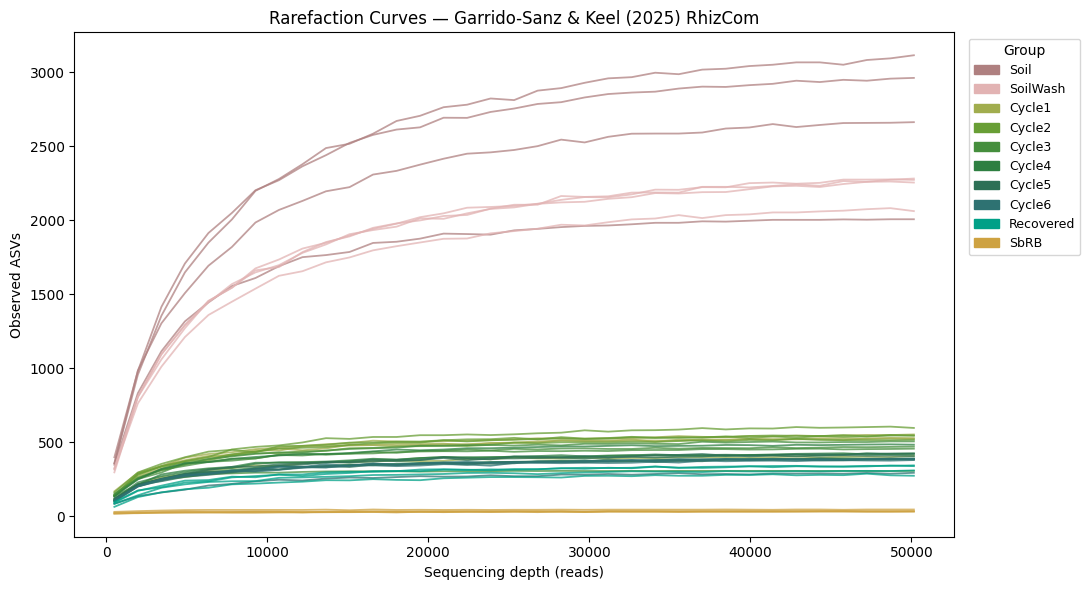

Minimum sequencing depth across 40 samples: 50157


In [21]:
# Plotting palette and group order from metadata
name_order = (
    metadata.drop_duplicates("Name")
    .sort_values("Order")["Name"]
    .tolist()
)
name_colors = (
    metadata.drop_duplicates("Name")
    .set_index("Name")["RGBcol"]
    .to_dict()
)

otu_taxa_rows = ps2.otu_table.to_dataframe()
if not ps2.otu_table.taxa_are_rows:
    otu_taxa_rows = otu_taxa_rows.T  # taxa × samples

min_depth = int(ps2.sample_sums().min())
depths = np.linspace(500, min_depth, 35, dtype=int)


def rarefaction_curve(counts_int, depths, rng):
    total = counts_int.sum()
    taxa_pool = np.repeat(np.arange(len(counts_int)), counts_int)
    results = []
    for d in depths:
        if d > total:
            break
        samp = rng.choice(taxa_pool, size=d, replace=False)
        results.append((d, len(np.unique(samp))))
    return np.array(results)


fig, ax = plt.subplots(figsize=(11, 6))
for sample in ps2.sample_names:
    cnts = otu_taxa_rows[sample].values.astype(int)
    name = metadata.loc[sample, "Name"]
    curve = rarefaction_curve(cnts, depths, RNG)
    if len(curve):
        ax.plot(curve[:, 0], curve[:, 1], color=name_colors.get(name, "grey"),
                alpha=0.75, linewidth=1.3)

handles = [mpatches.Patch(color=name_colors[n], label=n)
           for n in name_order if n in name_colors]
ax.legend(handles=handles, title="Group", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=9)
ax.set_xlabel("Sequencing depth (reads)")
ax.set_ylabel("Observed ASVs")
ax.set_title("Rarefaction Curves — Garrido-Sanz & Keel (2025) RhizCom")
plt.tight_layout()
plt.show()
print(f"Minimum sequencing depth across {ps2.nsamples} samples: {min_depth}")

---
### 4. Class-Level Taxonomic Composition

Relative abundance bar plots at **Class** level reproduce R's stacked bar charts (`geom_bar(stat="identity", position="stack")` faceted by group). ASVs are first aggregated with `tax_glom(ps2, "Class")` and then normalized to relative abundance per sample. Only the 15 most abundant classes are labeled; remaining classes are collapsed into "Other".

| R call | pyloseq equivalent |
|--------|-------------------|
| `tax_glom(ps2, taxrank="Class")` | `tax_glom(ps2, "Class")` |
| `transform_sample_counts(ps2, function(x) x/sum(x)*100)` | `transform_sample_counts(ps2_class, lambda x: x/x.sum()*100)` |
| `ggplot(..., aes(fill=Class)) + facet_wrap(~Name, scales="free_x")` | plotnine equivalent |

In [ ]:
from plotnine import (
    aes,
    element_blank,
    element_text,
    facet_wrap,
    geom_bar,
    ggplot,
    ggtitle,
    labs,
    scale_fill_manual,
    theme,
    theme_bw,
)

# R: Class_glom = tax_glom(ps2.css.prop, taxrank="Class")
ps2_class = tax_glom(ps2, "Class")
ps2_rel = transform_sample_counts(ps2_class, lambda x: x / x.sum() * 100)

# psmelt joins both sample_data and tax_table. "Order" appears in both (propagation order
# vs. taxonomic rank), so psmelt suffixes them _x/_y. Map sample-level order directly from
# metadata to avoid the collision.
melted = psmelt(ps2_rel)
melted["_sample_order"] = melted["Sample"].map(metadata["Order"])

# Identify top 15 classes and collapse rest
top_classes = (
    melted.groupby("Class", observed=True)["Abundance"]
    .mean().sort_values(ascending=False).head(15).index.tolist()
)
melted["Class_plot"] = melted["Class"].where(melted["Class"].isin(top_classes), "Other")

# Ordered sample x-axis and facet grouping
sample_order = (
    melted.sort_values(["_sample_order", "Sample"])["Names_rep"]
    .drop_duplicates().tolist()
)
melted["Names_rep"] = pd.Categorical(melted["Names_rep"], categories=sample_order, ordered=True)
melted["Name"] = pd.Categorical(melted["Name"], categories=name_order, ordered=True)

class_palette = [
    "#25725d", "#439b5b", "#7bc369", "#abd69a", "#d8e8b0",
    "#cccda7", "#bfb77b", "#7e9998", "#83bbbf", "#61acc1",
    "#58a0c4", "#7087c3", "#8973b4", "#512972", "#c08030", "#aaaaaa",
]
class_color_map = dict(zip(top_classes + ["Other"], class_palette[:len(top_classes) + 1]))

p = (
    ggplot(melted, aes(x="Names_rep", y="Abundance", fill="Class_plot"))
    + geom_bar(stat="identity", position="stack", width=1)
    + facet_wrap("~Name", scales="free_x", nrow=1)
    + scale_fill_manual(values=class_color_map)
    + labs(x="", y="Relative abundance (%)", fill="Class")
    + ggtitle("Class-level composition — RhizCom propagation series")
    + theme_bw()
    + theme(
        axis_text_x=element_text(angle=90, vjust=0.5, hjust=1, size=6),
        strip_text=element_text(size=7),
        legend_position="bottom",
        figure_size=(17, 6),
    )
)
p

---
### 5. Alpha Diversity

Four alpha diversity metrics are computed for each of the 40 samples:

| Metric | R call | Python call |
|--------|--------|------------|
| Observed ASVs | `plot_richness(ps2, measures="Observed")` | `estimate_richness(ps2, measures=["Observed"])` |
| Shannon index | `plot_richness(ps2, measures="Shannon")` | `estimate_richness(ps2, measures=["Shannon"])` |
| Simpson index | `plot_richness(ps2, measures="Simpson")` | `estimate_richness(ps2, measures=["Simpson"])` |
| Faith's PD | `picante::pd(otu_table(ps2), phy_tree(ps2))` | `skbio.diversity.alpha_diversity("faith_pd", ...)` |

**Faith's PD requires a rooted tree.** The IQ-TREE output is unrooted; we midpoint-root it (equivalent to `phangorn::midpoint(phy_tree(ps))` used elsewhere in the R script).

**Statistical testing.** R uses `agricolae::kruskal` (Kruskal-Wallis + FDR post-hoc). We use `scipy.stats.kruskal` for the omnibus test across all 10 groups.

In [ ]:
# Observed, Shannon, Simpson
# R: plot_richness(ps2, x="Name", measures=c("Observed","Shannon","Simpson"))
richness = estimate_richness(ps2, measures=["Observed", "Shannon", "Simpson"])
richness.index.name = "id_samples"
# Join Name and propagation Order from metadata (rename to avoid "Order" taxonomy collision)
richness = richness.join(metadata[["Name"]].rename_axis("id_samples"))
richness["group_order"] = richness.index.map(metadata["Order"])

# Faith's PD — requires midpoint-rooted tree
# R: pd = pd(otu_table(ps2), phy_tree(ps2), include.root=FALSE)
rooted_node = ps2.phy_tree._tree.root_at_midpoint()
ps2_rooted = Phyloseq(
    otu=ps2.otu_table,
    sam=ps2.sample_data,
    tax=ps2.tax_table,
    tree=PhyTree(rooted_node),
)

otu_for_pd = ps2_rooted.otu_table.to_dataframe()
if not ps2_rooted.otu_table.taxa_are_rows:
    otu_for_pd = otu_for_pd.T  # taxa × samples

tree_tips = {n.name for n in rooted_node.tips()}
common = [t for t in otu_for_pd.index if t in tree_tips]
otu_aligned = otu_for_pd.loc[common].T  # samples × taxa

# skbio faith_pd uses `taxa=` (not `otu_ids=`) for column names
faith_pd_vals = alpha_diversity(
    "faith_pd",
    otu_aligned.values.astype(int),
    ids=list(otu_aligned.index),
    tree=rooted_node,
    taxa=list(otu_aligned.columns),
)
richness["FaithPD"] = faith_pd_vals

print("Alpha diversity (mean ± SD per group):")
print(
    richness.groupby("Name")[["Observed", "Shannon", "Simpson", "FaithPD"]]
    .agg(["mean", "std"])
    .round(2)
    .to_string()
)

In [ ]:
# Plot: 2×2 boxplots, one panel per metric
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
measures_plot = [
    ("Observed", "Observed ASVs"),
    ("Shannon",  "Shannon index"),
    ("Simpson",  "Simpson index"),
    ("FaithPD",  "Faith's PD"),
]

for ax, (col, ylabel) in zip(axes.flat, measures_plot):
    for xi, name in enumerate(name_order):
        group = richness[richness["Name"] == name]
        y = group[col].dropna().values
        color = name_colors.get(name, "grey")
        bp = ax.boxplot(
            y, positions=[xi], widths=0.55, patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.65),
            medianprops=dict(color="black", linewidth=1.5),
            whiskerprops=dict(linewidth=0.8),
            capprops=dict(linewidth=0.8),
            flierprops=dict(marker="o", markersize=3, alpha=0.5),
        )
        jitter = RNG.uniform(-0.18, 0.18, len(y))
        ax.scatter(xi + jitter, y, color=color, s=22, zorder=3, alpha=0.9, edgecolors="grey", linewidths=0.3)

    ax.set_xticks(range(len(name_order)))
    ax.set_xticklabels(name_order, rotation=90, fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(col)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

plt.suptitle("Alpha Diversity — RhizCom Propagation Series", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# Kruskal-Wallis omnibus test across all groups
# R: kruskal(diver_filt$value, diver_filt$Name, alpha=0.05, p.adj="fdr")
print("Kruskal-Wallis test across all 10 groups:")
for col, _ in measures_plot:
    groups = [richness.loc[richness["Name"] == n, col].dropna().values for n in name_order]
    stat, p = kruskal(*groups)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {col:<12}: H = {stat:6.2f},  p = {p:.4f}  {sig}")

---
### 6. Alpha Diversity Correlation with Propagation Cycle

For the six cycle samples (Cycle1–Cycle6), does diversity change monotonically with propagation number? Spearman correlation tests for a rank-order trend between cycle number and each diversity metric.

| R call | Python equivalent |
|--------|------------------|
| `diver.ob.good = filter(diver.ob$data, grepl("Cycle", Name))` | `richness[richness["Name"].str.startswith("Cycle")]` |
| `stat_cor(method="spearman")` | `scipy.stats.spearmanr` |

In [ ]:
# R: diver.ob.good = filter(diver.ob$data, grepl("Cycle", Name))
#    stat_cor(method="spearman")
cycles = richness[richness["Name"].str.startswith("Cycle")].copy()
cycles["CycleNum"] = cycles["Name"].str.replace("Cycle", "").astype(int)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (col, ylabel) in zip(axes, measures_plot):
    x = cycles["CycleNum"].values
    y = cycles[col].values
    rho, p = spearmanr(x, y)

    colors = [name_colors.get(f"Cycle{c}", "grey") for c in x]
    ax.scatter(x, y, c=colors, s=55, zorder=3, edgecolors="grey", linewidths=0.4)

    # Linear trend line for visual guidance
    z = np.polyfit(x, y, 1)
    xfit = np.linspace(x.min(), x.max(), 100)
    ax.plot(xfit, np.poly1d(z)(xfit), "k--", linewidth=0.9, alpha=0.5)

    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.set_xlabel("Propagation cycle")
    ax.set_ylabel(ylabel)
    ax.set_title(f"ρ = {rho:.3f}, p = {p:.3f} {sig}")
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.grid(alpha=0.3)

plt.suptitle("Alpha Diversity vs. Propagation Cycle — Spearman Correlation", y=1.02)
plt.tight_layout()
plt.show()

---
### 7. Beta Diversity — GUniFrac PCoA

With a phylogenetic tree available, we compute **GUniFrac** distances (Chen et al. 2012) — a family of tree-weighted distances that generalizes weighted (alpha = 1) and unweighted (alpha = 0) UniFrac:

| Key | Distance | Sensitivity |
|-----|----------|-------------|
| `d_1` | Weighted UniFrac | Proportional to abundance |
| `d_UW` | Unweighted UniFrac | Presence/absence only |
| `d_0.5` | GUniFrac α = 0.5 | Balanced between abundance and occurrence |

PCoA (Principal Coordinates Analysis) embeds each distance matrix in 2D. 80% confidence ellipses per group are drawn with `stat_ellipse`.

The tree must be **rooted** for UniFrac computation (R calls `phangorn::midpoint` on the pruned tree). We root at the midpoint of the longest path, matching R's default.

| R call | pyloseq equivalent |
|--------|-------------------|
| `GUniFrac(otu.tab, midpoint(phy_tree(ps)), alpha=c(0,0.5,1))$unifracs` | `gunifrac(ps, alpha=(0, 0.5, 1))` |
| `ordinate(ps, method="PCoA", distance=dm)` | `ordinate(ps, method="PCoA", distance=dm)` |
| `plot_ordination(ps, ord, color="Name")` | `plot_ordination(ps, ord, color="Name")` |

In [ ]:
# Relative abundance for Bray-Curtis; raw counts + rooted tree for GUniFrac
ps2_rel_count = transform_sample_counts(ps2_rooted, lambda x: x / x.sum())

# R: GUniFrac(as.matrix(otu_table(physeq_subset)), midpoint(phy_tree(physeq_subset)),
#             alpha=c(0, 0.5, 1))$unifracs
print("Computing GUniFrac distances (d_1, d_UW, d_0.5)...")
unifracs = gunifrac(ps2_rooted, alpha=(0, 0.5, 1))
d1  = unifracs["d_1"]    # Weighted UniFrac
du  = unifracs["d_UW"]   # Unweighted UniFrac
d05 = unifracs["d_0.5"]  # GUniFrac alpha = 0.5

# Bray-Curtis on relative abundance
bray = pldistance(ps2_rel_count, method="bray")

print("Running PCoA ordinations...")
pcoa_d1  = ordinate(ps2_rooted, method="PCoA", distance=d1)
pcoa_du  = ordinate(ps2_rooted, method="PCoA", distance=du)
pcoa_d05 = ordinate(ps2_rooted, method="PCoA", distance=d05)
pcoa_bray = ordinate(ps2_rel_count, method="PCoA", distance=bray)
print("Done.")

In [ ]:
from plotnine import scale_color_manual, scale_fill_manual, stat_ellipse, geom_point

meta_df = ps2_rooted.sample_data.to_frame()


def pcoa_plot(result, ps_obj, title):
    """PCoA scatter with 80% t-ellipses per group."""
    scores = result.samples.copy().join(ps_obj.sample_data.to_frame())
    pct = result.proportion_explained
    scores["Name"] = pd.Categorical(scores["Name"], categories=name_order, ordered=True)
    return (
        ggplot(scores, aes(x="PC1", y="PC2", color="Name", fill="Name"))
        + geom_point(size=3, alpha=0.85)
        + stat_ellipse(aes(group="Name"), type="t", level=0.80,
                       geom="polygon", alpha=0.10)
        + scale_color_manual(values=name_colors)
        + scale_fill_manual(values=name_colors)
        + theme_bw()
        + theme(figure_size=(8, 6))
        + ggtitle(title)
        + labs(
            x=f"PC1 [{pct.iloc[0]*100:.1f}%]",
            y=f"PC2 [{pct.iloc[1]*100:.1f}%]",
        )
    )


# R: ord = ordinate(ps2.css.prop, method="PCoA", distance="bray")
#    plot_ordination(ps2.css.prop, ord, color="Name") + geom_point(size=5)
pcoa_plot(pcoa_bray, ps2_rel_count, "Bray-Curtis PCoA")

In [ ]:
pcoa_plot(pcoa_d1, ps2_rooted, "GUniFrac Weighted UniFrac (d_1) PCoA")

In [ ]:
pcoa_plot(pcoa_du, ps2_rooted, "GUniFrac Unweighted UniFrac (d_UW) PCoA")

In [ ]:
pcoa_plot(pcoa_d05, ps2_rooted, "GUniFrac α = 0.5 (d_0.5) PCoA")

---
### 8. PERMANOVA — Does Community Structure Differ Across Groups?

PERMANOVA (`adonis` in R's vegan) partitions variance in a distance matrix by group. We test whether microbial community composition differs significantly across the 10 sample groups (Soil, SoilWash, Cycle1–6, Recovered, SbRB).

| R call | Python equivalent |
|--------|------------------|
| `adonis(as.dist(d5) ~ Name, data=sample_data(ps2))` | `skbio.stats.distance.permanova(dm, groups)` |

In [ ]:
# R: adonis(as.dist(d5) ~ Name, data=sample_data(ps2), permutations=999)
print("PERMANOVA results (999 permutations) — H₀: no community composition difference across groups\n")
for label, dm in [
    ("Bray-Curtis",               bray),
    ("Weighted UniFrac (d_1)",    d1),
    ("Unweighted UniFrac (d_UW)", du),
    ("GUniFrac α=0.5 (d_0.5)",   d05),
]:
    groups = meta_df.loc[list(dm.ids), "Name"]
    res = permanova(dm, groups, permutations=999)
    sig = "***" if res["p-value"] < 0.001 else "**" if res["p-value"] < 0.01 else "*" if res["p-value"] < 0.05 else "ns"
    print(f"{label:<35} pseudo-F = {res['test statistic']:7.3f}   p = {res['p-value']:.3f}  {sig}")

---
### 9. Sample Similarity — Bray-Curtis Distance Heatmap

A clustermap of the pairwise Bray-Curtis dissimilarity matrix reveals which groups cluster together. R uses `ComplexHeatmap::Heatmap`; we use `seaborn.clustermap` with hierarchical clustering and group-colored annotation bars.

| R call | Python equivalent |
|--------|------------------|
| `phyloseq::distance(ps2.css.prop, method="bray")` | `pyloseq.distance(ps2_rel_count, method="bray")` |
| `ComplexHeatmap::Heatmap(bray, column_km=3, row_km=3)` | `seaborn.clustermap(bray_df)` |

In [ ]:
# R: bray = as.data.frame(as.matrix(phyloseq::distance(ps2.css.prop, method="bray")))
#    Heatmap(bray, ...)
bray_mat = pd.DataFrame(bray.data, index=bray.ids, columns=bray.ids)

# Annotation colors: one color per sample based on group membership
row_colors = pd.Series(
    {s: name_colors.get(meta_df.loc[s, "Name"], "grey") for s in bray_mat.index},
    name="Group",
)

g = sns.clustermap(
    bray_mat,
    row_cluster=True,
    col_cluster=True,
    row_colors=row_colors,
    col_colors=row_colors,
    cmap="YlOrRd",
    figsize=(11, 10),
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "Bray-Curtis dissimilarity"},
)
g.fig.suptitle("Bray-Curtis Dissimilarity — RhizCom Propagation Series", y=1.01)

# Group legend
patches = [mpatches.Patch(color=name_colors[n], label=n)
           for n in name_order if n in name_colors]
g.fig.legend(handles=patches, title="Group",
             bbox_to_anchor=(1.18, 0.75), loc="upper right", fontsize=9)
plt.show()

---
### 10. ASV Source Tracking — Cycle6 Origins

For each ASV present in **Cycle6** (the final propagation cycle), we ask: can its presence be traced to another group in the experiment? Three categories are assigned:

| Category | Criterion |
|----------|----------|
| Traced: SoilWash or SbRB | ASV present in SoilWash > 0 **or** SbRB > 0 |
| Traced: earlier cycles / Soil | Not in SoilWash/SbRB, but mean abundance across Cycle1–5 > 0 or Soil > 0 |
| Not tracked | Absent from all other groups |

Replicates are pooled (summed) per group before the comparison. This reproduces the doughnut chart from the R script (section 13.2).

| R call | Python equivalent |
|--------|------------------|
| `merge_samples(ps2.css.merg, "Name", fun=mean)` | Group-wise sum on OTU table |
| `filter(ps2.css.merg.df, Cycle6 > 0 & SoilWash > 0)` | Boolean indexing on grouped DataFrame |
| `ggplot(...) + geom_rect() + coord_polar(theta="y")` | `matplotlib.pyplot.pie` with donut styling |

In [ ]:
# R: ps2.css.merg = merge_samples(ps2.css, "Name", fun=mean)
# Pool replicates per group by summing raw counts
otu_taxa = ps2.otu_table.to_dataframe()
if not ps2.otu_table.taxa_are_rows:
    otu_taxa = otu_taxa.T  # taxa × samples

group_sums: dict[str, pd.Series] = {}
for name in name_order:
    group_samples = meta_df[meta_df["Name"] == name].index.tolist()
    group_sums[name] = otu_taxa[group_samples].sum(axis=1)
group_df = pd.DataFrame(group_sums)  # taxa × groups

# R: rhizcom = subset_samples(ps2.css.merg, Name=="Cycle6")
#    rhizcomASVs = taxa_names(prune_taxa(taxa_sums > 0, rhizcom))
cycle6_asvs = group_df[group_df["Cycle6"] > 0].index.tolist()
sub = group_df.loc[cycle6_asvs]

# Mean abundance across Cycles 1–5
cycle_cols = [f"Cycle{i}" for i in range(1, 6)]
cycles15_mean = sub[cycle_cols].mean(axis=1)


def classify_asv(row):
    if row["SoilWash"] > 0 or row["SbRB"] > 0:
        return "Traced: SoilWash / SbRB"
    elif cycles15_mean[row.name] > 0 or row["Soil"] > 0:
        return "Traced: Cycles 1–5 / Soil"
    else:
        return "Not tracked"


categories = sub.apply(classify_asv, axis=1)
counts = categories.value_counts()

cat_colors = {
    "Traced: SoilWash / SbRB":  "#4e79a7",
    "Traced: Cycles 1–5 / Soil": "#f28e2b",
    "Not tracked":               "#e15759",
}
labels = counts.index.tolist()
sizes  = counts.values
colors = [cat_colors.get(l, "grey") for l in labels]

fig, ax = plt.subplots(figsize=(7, 6))
wedges, _, autotexts = ax.pie(
    sizes, labels=None, colors=colors,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p / 100 * sum(sizes)))})",
    startangle=90, pctdistance=0.75,
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2},
)
for t in autotexts:
    t.set_fontsize(9)
ax.legend(wedges, labels, title="ASV origin",
          loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=9)
ax.set_title(
    f"Cycle6 ASV source tracking\n({len(cycle6_asvs)} ASVs present in Cycle6)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

print("\nCycle6 ASV source tracking:")
for cat in labels:
    print(f"  {cat}: {counts[cat]} ASVs ({counts[cat] / len(cycle6_asvs) * 100:.1f}%)")
print(f"  Total Cycle6 ASVs: {len(cycle6_asvs)}")